<a href="https://colab.research.google.com/github/devendrarapeti984-byte/ML-Projects/blob/main/customer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

In [ ]:
# Creating Mall Customers Dataset with 200 Customers

import pandas as pd
import numpy as np

np.random.seed(42)

# Generate data
customer_id = np.arange(1, 201)

gender = np.random.choice(['Male', 'Female'], 200)

age = np.random.randint(18, 70, 200)

annual_income = np.random.randint(15, 140, 200)

spending_score = np.random.randint(1, 100, 200)

# Create DataFrame
mall_data = pd.DataFrame({
    'CustomerID': customer_id,
    'Gender': gender,
    'Age': age,
    'Annual Income (k$)': annual_income,
    'Spending Score (1-100)': spending_score
})

# Save CSV file
mall_data.to_csv('Mall_Customers.csv', index=False)

# Display first 10 rows
print(mall_data.head(10))

# Check shape
print("\nDataset Shape:", mall_data.shape)

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   49                  68                      86
1           2  Female   56                  22                      57
2           3    Male   66                  41                      29
3           4    Male   69                  41                      78
4           5    Male   49                 112                      92
5           6  Female   21                  35                      69
6           7    Male   47                  44                      47
7           8    Male   54                 111                      94
8           9    Male   40                  42                      62
9          10  Female   56                 125                      69

Dataset Shape: (200, 5)


In [ ]:
# loading the data from csv file to a Pandas DataFrame
customer_data = pd.read_csv('Mall_Customers.csv')

In [ ]:
# first 5 rows in the dataframe
customer_data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,49,68,86
1,2,Female,56,22,57
2,3,Male,66,41,29
3,4,Male,69,41,78
4,5,Male,49,112,92


In [ ]:
# finding the number of rows and columns
customer_data.shape

(200, 5)

In [ ]:
# getting some informations about the dataset
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
# checking for missing values
customer_data.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
X = customer_data.iloc[:,[3,4]].values

In [ ]:
print(X)

[[ 68  86]
 [ 22  57]
 [ 41  29]
 [ 41  78]
 [112  92]
 [ 35  69]
 [ 44  47]
 [111  94]
 [ 42  62]
 [125  69]
 [ 78  76]
 [111  16]
 [ 83  90]
 [138  90]
 [ 75  48]
 [ 62  85]
 [ 33  39]
 [ 18  33]
 [ 49  94]
 [ 78  23]
 [ 63  10]
 [ 31  69]
 [ 58  34]
 [106  52]
 [ 44  95]
 [107  10]
 [ 60  19]
 [131  58]
 [ 20  96]
 [113   1]
 [138  69]
 [119   4]
 [ 51  16]
 [ 38  24]
 [107  80]
 [127   2]
 [ 60  92]
 [ 67  32]
 [109  91]
 [113  84]
 [ 74  24]
 [111  12]
 [130  50]
 [ 77  35]
 [139  33]
 [ 99  33]
 [ 46  61]
 [101  51]
 [ 47  43]
 [ 81  12]
 [ 32  67]
 [ 39  65]
 [120  33]
 [109  40]
 [ 68  74]
 [ 72  43]
 [ 81  44]
 [118  29]
 [ 60  13]
 [ 38  12]
 [128  95]
 [ 46  46]
 [ 61   2]
 [100  35]
 [ 37  87]
 [ 80  81]
 [ 41  90]
 [120   8]
 [ 16  93]
 [104  26]
 [ 31  74]
 [118  90]
 [ 47  34]
 [ 23   7]
 [ 57  68]
 [132  58]
 [ 62  75]
 [ 53  29]
 [107  36]
 [ 56  89]
 [133  21]
 [ 40  36]
 [113  10]
 [ 64  73]
 [ 39  24]
 [ 38  64]
 [ 27  99]
 [ 74  49]
 [136  99]
 [ 21  36]
 [ 71  82]

In [ ]:
# finding wcss value for different number of clusters

wcss = []

for i in range(1,11):
  kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
  kmeans.fit(X)

  wcss.append(kmeans.inertia_)

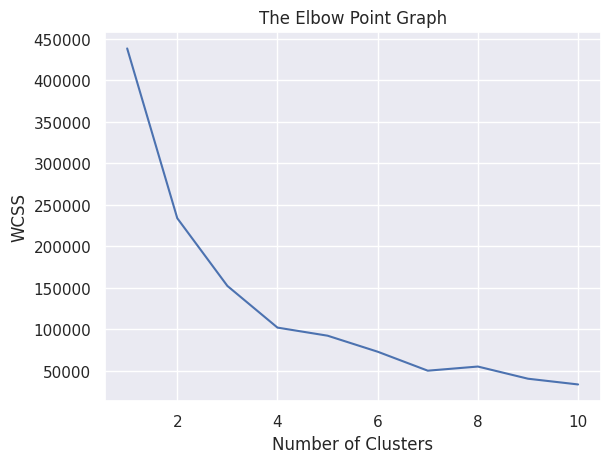

In [ ]:
# plot an elbow graph

sns.set()
plt.plot(range(1,11), wcss)
plt.title('The Elbow Point Graph')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=0)

# return a label for each data point based on their cluster
Y = kmeans.fit_predict(X)

print(Y)


[4 1 3 1 2 1 3 2 1 2 4 0 4 2 4 4 3 3 1 3 3 1 3 0 1 0 3 2 1 0 2 0 3 3 2 0 4
 3 2 2 3 0 0 3 0 0 1 0 3 3 1 1 0 0 4 4 4 0 3 3 2 3 3 0 1 4 1 0 1 0 1 2 3 3
 4 2 4 3 0 4 0 3 0 4 3 1 1 4 2 3 4 1 3 3 4 1 0 3 1 0 0 2 1 0 0 4 1 2 4 0 4
 3 4 3 4 0 1 3 4 0 4 4 4 4 3 4 2 3 0 0 1 4 3 0 2 3 0 4 1 0 0 2 0 3 2 4 4 3
 1 3 2 2 0 3 3 3 0 4 3 0 3 4 0 0 0 0 4 3 1 1 0 1 4 0 3 0 1 0 0 4 0 0 2 2 1
 3 3 2 4 3 4 1 0 2 4 4 3 3 3 2]


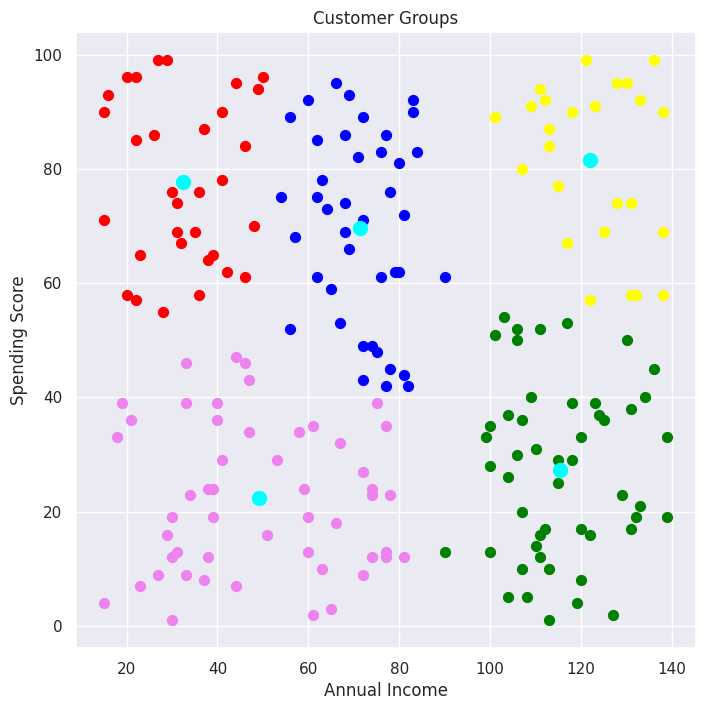

In [ ]:
# plotting all the clusters and their Centroids

plt.figure(figsize=(8,8))
plt.scatter(X[Y==0,0], X[Y==0,1], s=50, c='green', label='Cluster 1')
plt.scatter(X[Y==1,0], X[Y==1,1], s=50, c='red', label='Cluster 2')
plt.scatter(X[Y==2,0], X[Y==2,1], s=50, c='yellow', label='Cluster 3')
plt.scatter(X[Y==3,0], X[Y==3,1], s=50, c='violet', label='Cluster 4')
plt.scatter(X[Y==4,0], X[Y==4,1], s=50, c='blue', label='Cluster 5')

# plot the centroids
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s=100, c='cyan', label='Centroids')

plt.title('Customer Groups')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.show()
